In [1]:
import tapas
from tapas.attacks.set_classifiers import RandomTargetedQueryFeature
from tapas.generators.generator import Raw
from utils.my_attack import MyAttack
from utils.benchmark_pipeline import BenchmarkPipeline
from utils.benchmark_metric import AUCMetric

estimating categorical probs
estimating approx kdes(histogram)
Attacking : Raw
Import datasets from data/generated_datasets/raw.pkl
COMPLEXITY:  2
COMPLEXITY:  20


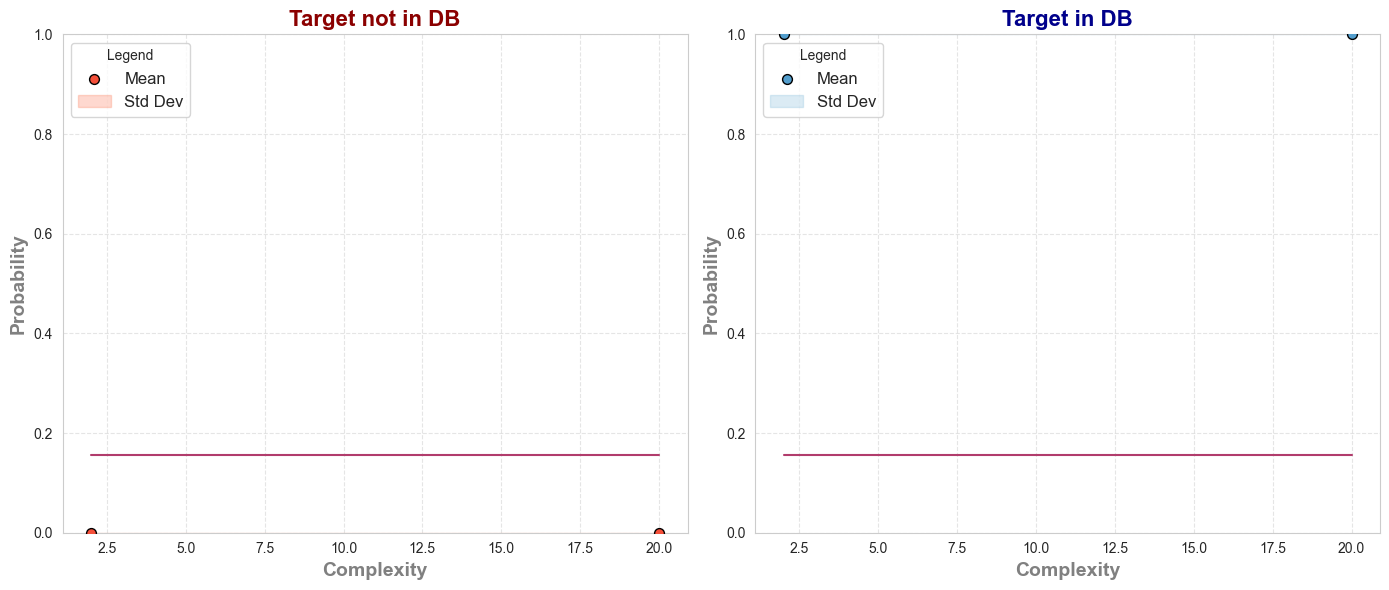

----[Benchmark ranks]----
Raw : F, 1.0


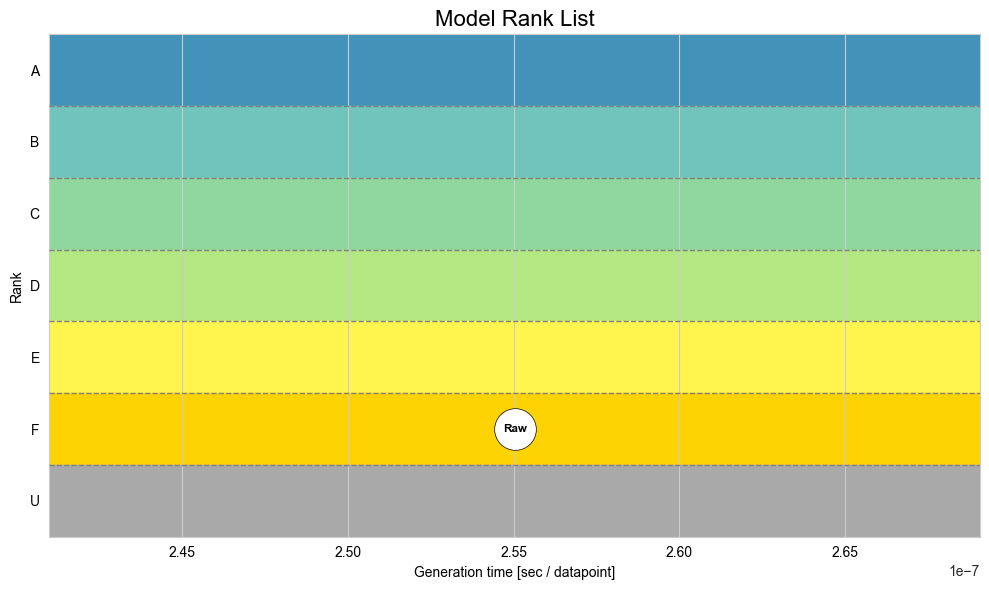

In [3]:
data = tapas.datasets.TabularDataset.read("data/dummy")
target_record = data.get_records([0])
data.drop_records([0], in_place=True)
attack = MyAttack(100, features=RandomTargetedQueryFeature(target_record,4,1))

#gen = ReprosynGenerator(DS_PRIVBAYES, label="PrivBayes", epsilon=1.0)

pipeline = BenchmarkPipeline(data, attack, [Raw()], target_record=target_record)
benchmarking_metric = AUCMetric([0, 0.17, 0.33, 0.5, 0.67, 0.83])


# just add the path to the folder where the generated data will be saved, the name of the file will be generated automatically
pipeline.run([2,20], 1, 2,  plot_style='double', benchmarking_metric=benchmarking_metric, imported_data_paths=[r'data/generated_datasets/raw.pkl'])

# if you want to run the attack without generating data, just set generate=False and add the path to the folder where the generated data will be saved
# pipeline.run_importing_data([2,4], 1, 2, imported_data_path="data/shadow_datasets_Raw_4.pkl")